# Módulo 3 — Interpretabilidade e explicações

Este notebook corresponde ao Módulo 3 do projeto. O objetivo é analisar e explicar os modelos treinados no Módulo 2, utilizando métodos de interpretabilidade direta, métodos globais, métodos locais e explicações baseadas em exemplos.

A análise incide sobre os modelos interpretáveis, nomeadamente Regressão Logística e Árvore de Decisão, e sobre o modelo selecionado no Módulo 2, o Random Forest afinado.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from pathlib import Path

from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import confusion_matrix


In [2]:
DATA_PATH = Path("../outputs/dados/diabetic_data_clean.csv")

df_model = pd.read_csv(DATA_PATH)

log_reg_model = joblib.load("../outputs/modelos/regressao_logistica.pkl")
tree_model = joblib.load("../outputs/modelos/arvore_decisao.pkl")
best_rf_model = joblib.load("../outputs/modelos/random_forest_afinado.pkl")

df_model.shape

(101766, 48)

## 3.1 Preparação dos dados para interpretabilidade

Nesta etapa são recriadas as variáveis explicativas e a variável-alvo, usando o mesmo conjunto de dados limpo utilizado no Módulo 2. Esta preparação é necessária para aplicar métodos de interpretabilidade aos modelos já treinados.

In [4]:
# Algumas variáveis são códigos administrativos e devem ser tratadas como categóricas
coded_categorical_cols = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

for col in coded_categorical_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].astype("object")

target = "readmitted_30"

cols_to_exclude = [
    "encounter_id",
    "patient_nbr",
    "readmitted",
    "readmitted_30"
]

X = df_model.drop(columns=cols_to_exclude)
y = df_model[target]

print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

Dimensão de X: (101766, 44)
Dimensão de y: (101766,)


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (81412, 44)
X_test: (20354, 44)


## 3.2 Interpretação direta da Regressão Logística

A Regressão Logística é um modelo interpretável porque os seus coeficientes indicam o sentido e a intensidade da associação entre cada variável transformada e a probabilidade prevista de readmissão em menos de 30 dias.

Coeficientes positivos indicam aumento da probabilidade prevista da classe positiva, enquanto coeficientes negativos indicam diminuição dessa probabilidade.

In [6]:
# Obter nomes das variáveis após o pré-processamento
preprocessor_logreg = log_reg_model.named_steps["preprocessor"]
classifier_logreg = log_reg_model.named_steps["classifier"]

feature_names = preprocessor_logreg.get_feature_names_out()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": classifier_logreg.coef_[0]
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

top_positive_coef = coef_df.sort_values("coefficient", ascending=False).head(15)
top_negative_coef = coef_df.sort_values("coefficient", ascending=True).head(15)

top_positive_coef

,feature,coefficient,abs_coefficient
287,cat__diag_1_356,2.258085,2.258085
1883,cat__diag_3_602,2.103580,2.103580
516,cat__diag_1_643,2.032758,2.032758
1595,cat__diag_3_250.91,1.998201,1.998201
781,cat__diag_2_136,1.984506,1.984506
1511,cat__diag_3_156,1.962310,1.962310
518,cat__diag_1_646,1.937957,1.937957
49,cat__discharge_disposition_id_15,1.910425,1.910425
2236,cat__diag_3_V60,1.870371,1.870371
214,cat__diag_1_271,1.840066,1.840066


In [7]:
top_negative_coef


,feature,coefficient,abs_coefficient
45,cat__discharge_disposition_id_11,-5.059147,5.059147
1288,cat__diag_2_807,-2.061936,2.061936
1832,cat__diag_3_537,-2.054210,2.054210
1981,cat__diag_3_736,-1.842632,1.842632
1026,cat__diag_2_429,-1.840497,1.840497
1393,cat__diag_2_999,-1.838083,1.838083
1067,cat__diag_2_481,-1.822202,1.822202
246,cat__diag_1_304,-1.817741,1.817741
912,cat__diag_2_289,-1.776506,1.776506
1264,cat__diag_2_782,-1.727023,1.727023


<Figure size 800x600 with 0 Axes>

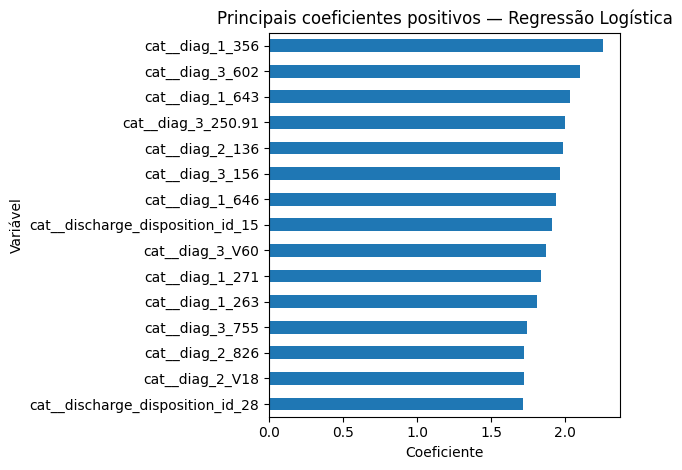

In [8]:
plt.figure(figsize=(8, 6))

top_positive_coef.sort_values("coefficient").plot(
    x="feature",
    y="coefficient",
    kind="barh",
    legend=False
)

plt.title("Principais coeficientes positivos — Regressão Logística")
plt.xlabel("Coeficiente")
plt.ylabel("Variável")
plt.tight_layout()

plt.savefig("../outputs/figuras/logreg_coeficientes_positivos.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 800x600 with 0 Axes>

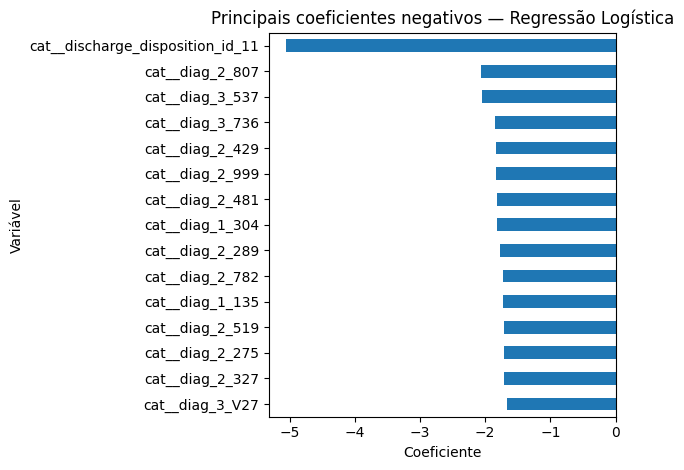

In [9]:
plt.figure(figsize=(8, 6))

top_negative_coef.sort_values("coefficient", ascending=False).plot(
    x="feature",
    y="coefficient",
    kind="barh",
    legend=False
)

plt.title("Principais coeficientes negativos — Regressão Logística")
plt.xlabel("Coeficiente")
plt.ylabel("Variável")
plt.tight_layout()

plt.savefig("../outputs/figuras/logreg_coeficientes_negativos.png", dpi=300, bbox_inches="tight")
plt.show()

Os coeficientes da Regressão Logística indicam que os diagnósticos registados e o tipo de alta hospitalar são variáveis relevantes para a previsão. Contudo, a interpretação clínica detalhada dos códigos de diagnóstico exige uma tabela de mapeamento entre códigos e categorias clínicas.

<Figure size 800x600 with 0 Axes>

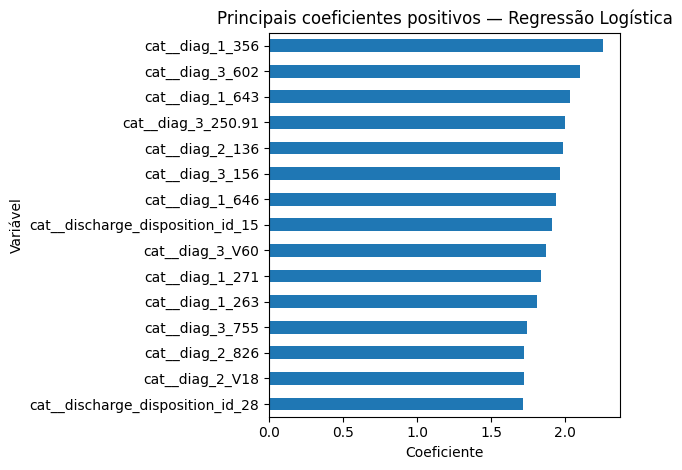

<Figure size 800x600 with 0 Axes>

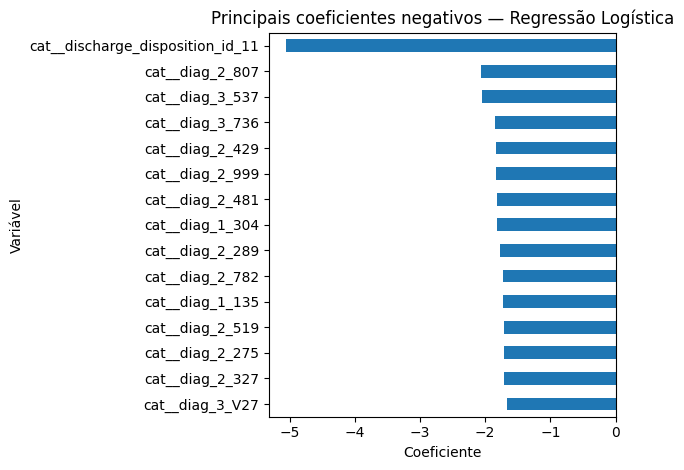

Coeficientes e gráficos guardados com sucesso.


In [10]:
from pathlib import Path

# Garantir que as pastas existem
Path("../outputs/figuras").mkdir(parents=True, exist_ok=True)
Path("../outputs/tabelas").mkdir(parents=True, exist_ok=True)

# Guardar tabelas dos coeficientes
coef_df.to_csv("../outputs/tabelas/coeficientes_regressao_logistica.csv", index=False)
top_positive_coef.to_csv("../outputs/tabelas/top_coeficientes_positivos_logreg.csv", index=False)
top_negative_coef.to_csv("../outputs/tabelas/top_coeficientes_negativos_logreg.csv", index=False)

# Guardar gráfico dos coeficientes positivos
plt.figure(figsize=(8, 6))
top_positive_coef.sort_values("coefficient").plot(
    x="feature",
    y="coefficient",
    kind="barh",
    legend=False
)
plt.title("Principais coeficientes positivos — Regressão Logística")
plt.xlabel("Coeficiente")
plt.ylabel("Variável")
plt.tight_layout()
plt.savefig("../outputs/figuras/logreg_coeficientes_positivos.png", dpi=300, bbox_inches="tight")
plt.show()

# Guardar gráfico dos coeficientes negativos
plt.figure(figsize=(8, 6))
top_negative_coef.sort_values("coefficient", ascending=False).plot(
    x="feature",
    y="coefficient",
    kind="barh",
    legend=False
)
plt.title("Principais coeficientes negativos — Regressão Logística")
plt.xlabel("Coeficiente")
plt.ylabel("Variável")
plt.tight_layout()
plt.savefig("../outputs/figuras/logreg_coeficientes_negativos.png", dpi=300, bbox_inches="tight")
plt.show()

print("Coeficientes e gráficos guardados com sucesso.")

## 3.3 Interpretação direta da Árvore de Decisão

A Árvore de Decisão permite uma interpretação direta através da sua estrutura hierárquica. Cada divisão representa uma regra de decisão baseada numa variável, permitindo compreender quais os atributos utilizados para separar os pacientes com maior ou menor probabilidade prevista de readmissão em menos de 30 dias.

Para manter a visualização legível, será apresentada apenas uma parte da árvore, limitada aos primeiros níveis.

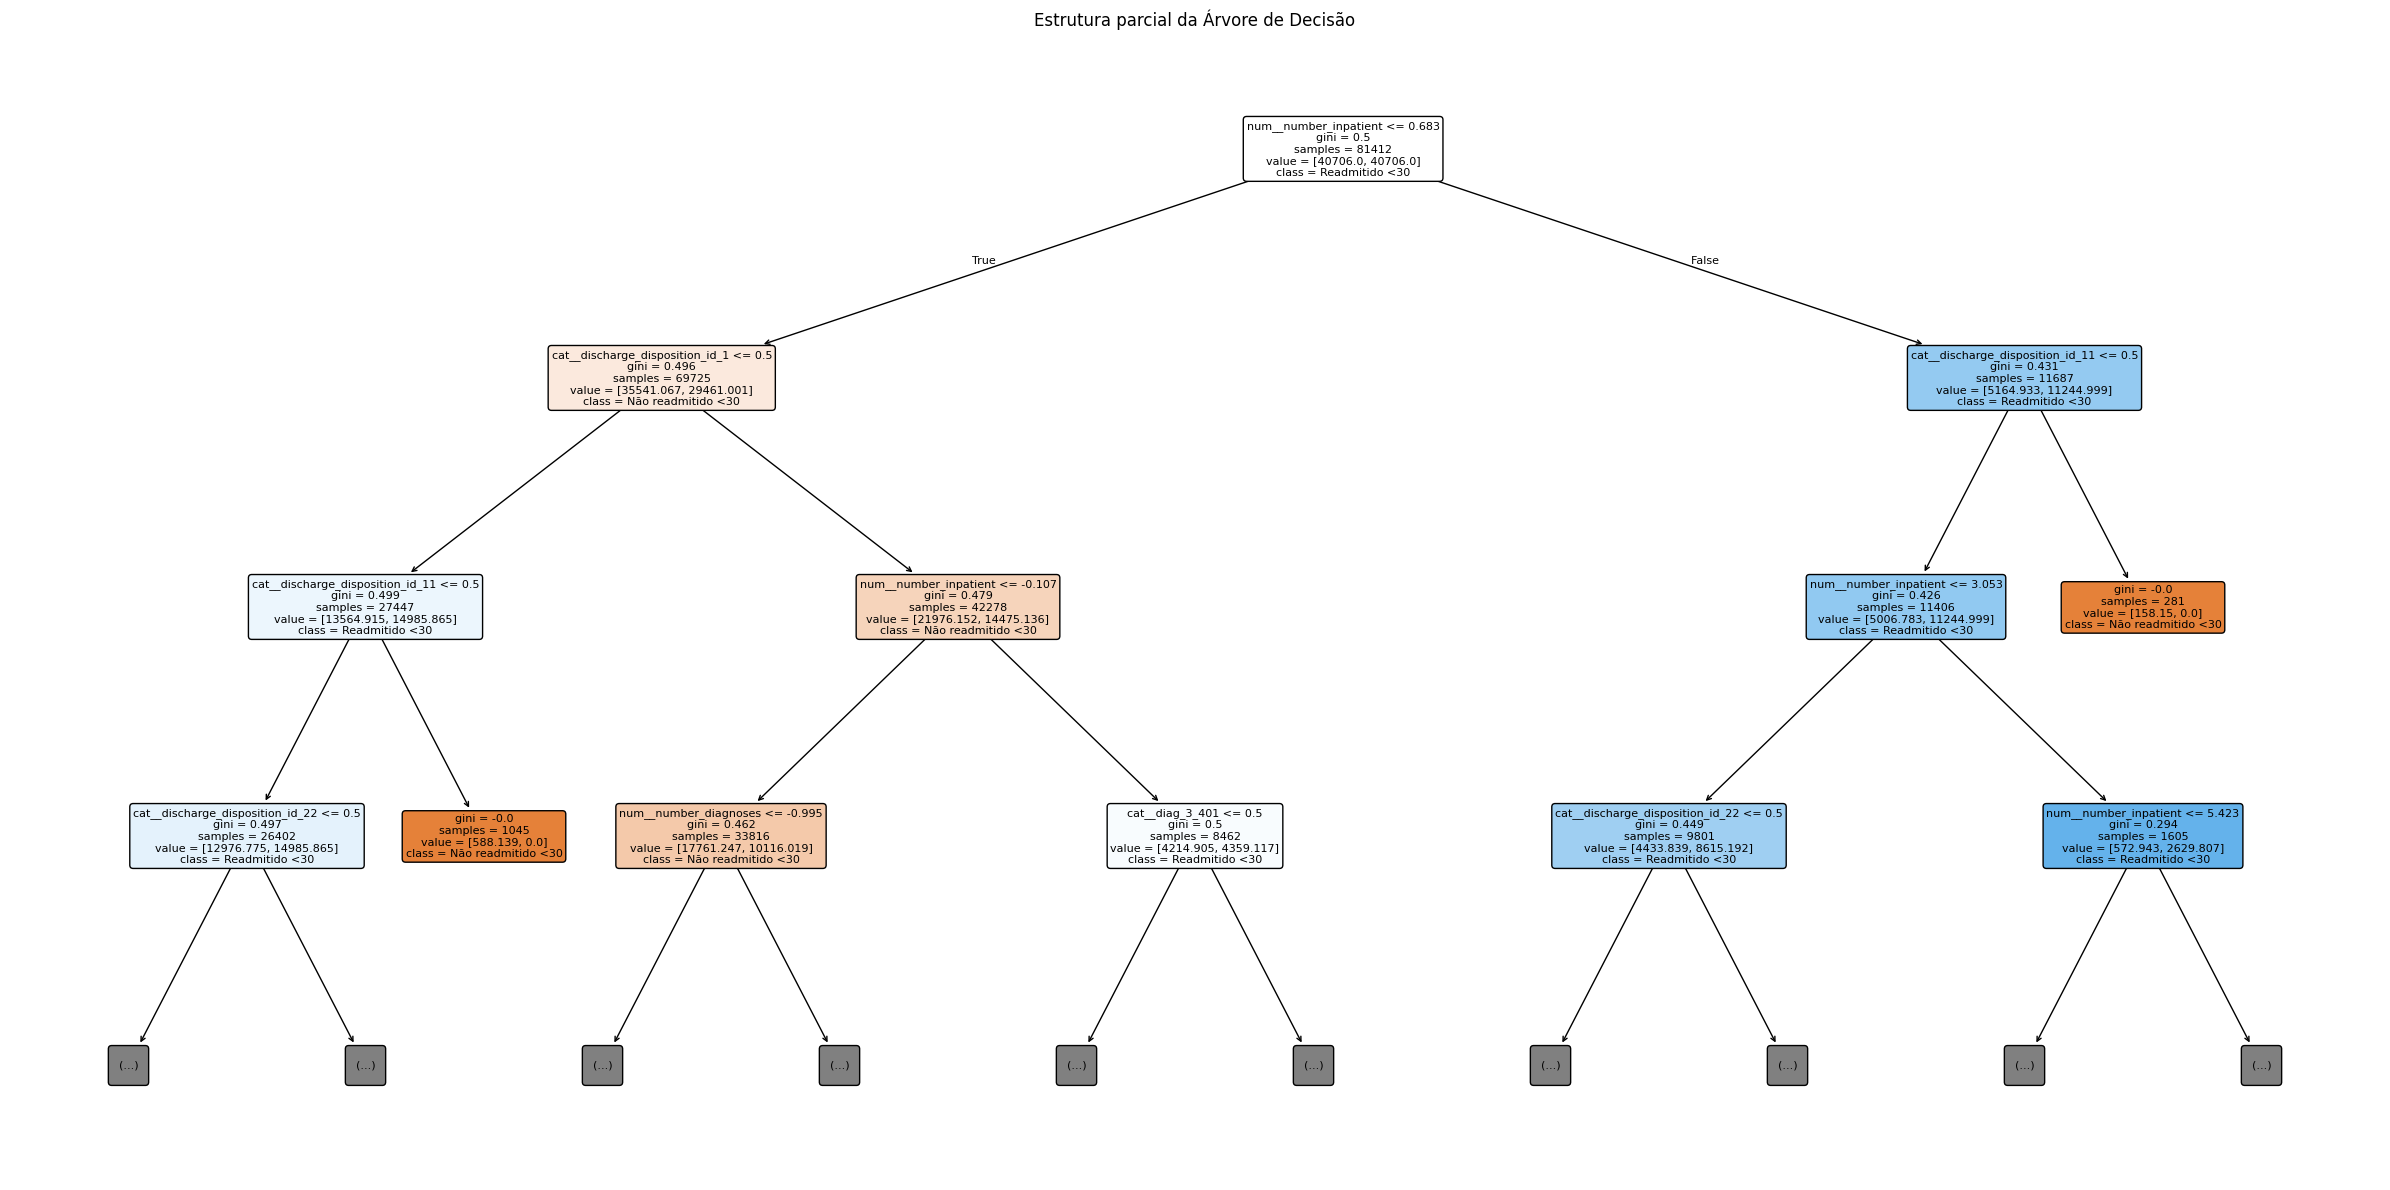

In [11]:
from sklearn.tree import plot_tree

preprocessor_tree = tree_model.named_steps["preprocessor"]
classifier_tree = tree_model.named_steps["classifier"]

tree_feature_names = preprocessor_tree.get_feature_names_out()

plt.figure(figsize=(24, 12))

plot_tree(
    classifier_tree,
    feature_names=tree_feature_names,
    class_names=["Não readmitido <30", "Readmitido <30"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("Estrutura parcial da Árvore de Decisão")
plt.tight_layout()

plt.savefig("../outputs/figuras/arvore_decisao_estrutura_parcial.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
tree_importance = pd.DataFrame({
    "feature": tree_feature_names,
    "importance": classifier_tree.feature_importances_
}).sort_values("importance", ascending=False)

tree_importance.head(20)


,feature,importance
6,num__number_inpatient,0.536198
35,cat__discharge_disposition_id_1,0.145805
45,cat__discharge_disposition_id_11,0.134110
55,cat__discharge_disposition_id_22,0.056378
7,num__number_diagnoses,0.028514
0,num__time_in_hospital,0.014284
39,cat__discharge_disposition_id_5,0.011846
1566,cat__diag_3_250,0.008985
1724,cat__diag_3_401,0.007688
1,num__num_lab_procedures,0.007482


In [13]:
tree_importance.to_csv("../outputs/tabelas/importancia_variaveis_arvore_decisao.csv", index=False)

In [14]:
tree_importance = pd.DataFrame({
    "feature": tree_feature_names,
    "importance": classifier_tree.feature_importances_
}).sort_values("importance", ascending=False)

tree_importance.head(20)

,feature,importance
6,num__number_inpatient,0.536198
35,cat__discharge_disposition_id_1,0.145805
45,cat__discharge_disposition_id_11,0.134110
55,cat__discharge_disposition_id_22,0.056378
7,num__number_diagnoses,0.028514
0,num__time_in_hospital,0.014284
39,cat__discharge_disposition_id_5,0.011846
1566,cat__diag_3_250,0.008985
1724,cat__diag_3_401,0.007688
1,num__num_lab_procedures,0.007482


In [15]:
tree_importance.to_csv(
    "../outputs/tabelas/importancia_variaveis_arvore_decisao.csv",
    index=False
)

<Figure size 800x600 with 0 Axes>

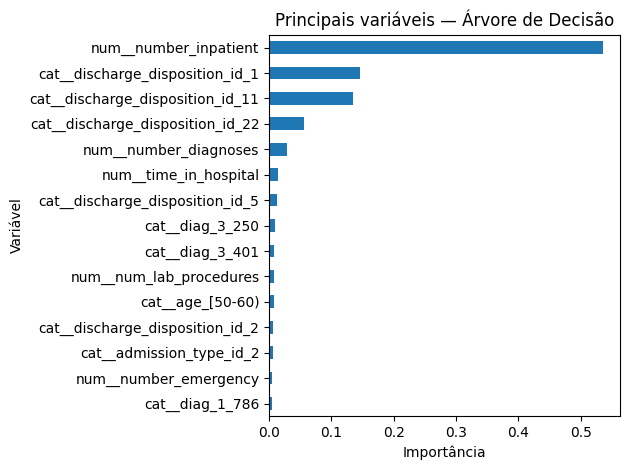

In [16]:
top_tree_importance = tree_importance.head(15)

plt.figure(figsize=(8, 6))

top_tree_importance.sort_values("importance").plot(
    x="feature",
    y="importance",
    kind="barh",
    legend=False
)

plt.title("Principais variáveis — Árvore de Decisão")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.tight_layout()

plt.savefig("../outputs/figuras/importancia_variaveis_arvore_decisao.png", dpi=300, bbox_inches="tight")
plt.show()


## 3.4 Método global — Importância das variáveis no Random Forest

Nesta etapa é analisada a importância global das variáveis no modelo Random Forest afinado. A importância das variáveis indica quais os atributos mais utilizados pelo modelo para reduzir a impureza nas árvores de decisão.

Este método permite obter uma visão global do comportamento do modelo, embora não explique previsões individuais.

In [17]:
# Extrair componentes do pipeline Random Forest afinado
preprocessor_rf = best_rf_model.named_steps["preprocessor"]
classifier_rf = best_rf_model.named_steps["classifier"]

# Obter nomes das variáveis após o pré-processamento
rf_feature_names = preprocessor_rf.get_feature_names_out()

# Importância das variáveis no Random Forest
rf_importance = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": classifier_rf.feature_importances_
}).sort_values("importance", ascending=False)

rf_importance.head(20)

,feature,importance
6,num__number_inpatient,0.173385
35,cat__discharge_disposition_id_1,0.068008
5,num__number_emergency,0.058981
55,cat__discharge_disposition_id_22,0.054714
45,cat__discharge_disposition_id_11,0.049214
3,num__num_medications,0.033195
7,num__number_diagnoses,0.030608
0,num__time_in_hospital,0.026675
37,cat__discharge_disposition_id_3,0.026388
845,cat__diag_2_250,0.018329


In [18]:
rf_importance.to_csv(
    "../outputs/tabelas/importancia_variaveis_random_forest.csv",
    index=False
)

<Figure size 800x600 with 0 Axes>

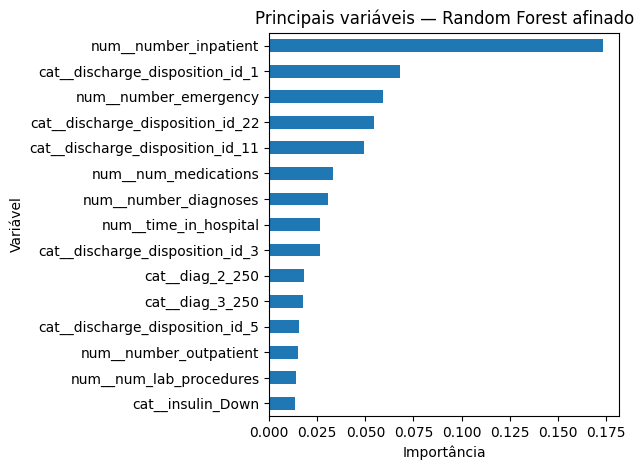

In [19]:
top_rf_importance = rf_importance.head(15)

plt.figure(figsize=(8, 6))

top_rf_importance.sort_values("importance").plot(
    x="feature",
    y="importance",
    kind="barh",
    legend=False
)

plt.title("Principais variáveis — Random Forest afinado")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.tight_layout()

plt.savefig("../outputs/figuras/importancia_variaveis_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

## 3.5 Método global — Permutation Importance

A Permutation Importance avalia a importância de cada variável medindo a redução do desempenho do modelo quando os valores dessa variável são baralhados.

Este método é útil porque avalia a importância das variáveis com base no impacto real no desempenho preditivo do modelo, em vez de depender apenas da estrutura interna do Random Forest.

In [20]:
from sklearn.inspection import permutation_importance

# Para reduzir o tempo de execução, usar uma amostra do conjunto de teste
X_test_sample = X_test.sample(n=3000, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

perm_importance = permutation_importance(
    best_rf_model,
    X_test_sample,
    y_test_sample,
    n_repeats=5,
    random_state=42,
    scoring="f1",
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    "feature": X_test_sample.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
}).sort_values("importance_mean", ascending=False)

perm_importance_df.head(20)

,feature,importance_mean,importance_std
12,number_inpatient,0.028404,0.006533
4,discharge_disposition_id,0.027458,0.003851
19,metformin,0.009059,0.001065
11,number_emergency,0.007855,0.001429
15,diag_3,0.007025,0.003082
13,diag_1,0.005746,0.002563
9,num_medications,0.004543,0.005615
2,age,0.004010,0.001689
14,diag_2,0.003034,0.001716
16,number_diagnoses,0.002847,0.002349


In [21]:
perm_importance_df.to_csv(
    "../outputs/tabelas/permutation_importance_random_forest.csv",
    index=False
)

<Figure size 800x600 with 0 Axes>

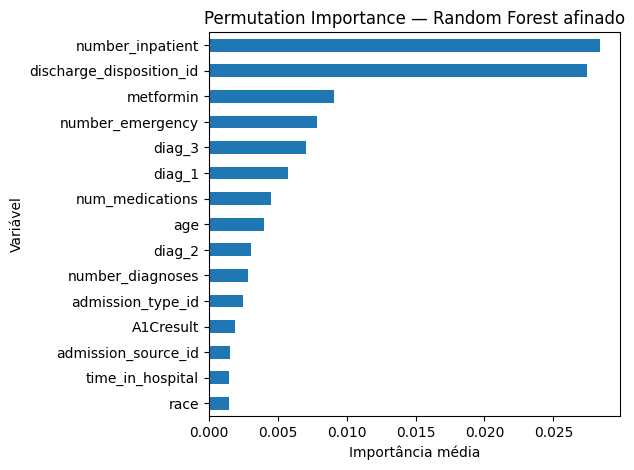

In [22]:
top_perm_importance = perm_importance_df.head(15)

plt.figure(figsize=(8, 6))

top_perm_importance.sort_values("importance_mean").plot(
    x="feature",
    y="importance_mean",
    kind="barh",
    legend=False
)

plt.title("Permutation Importance — Random Forest afinado")
plt.xlabel("Importância média")
plt.ylabel("Variável")
plt.tight_layout()

plt.savefig("../outputs/figuras/permutation_importance_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

## 3.6 Método global — Partial Dependence Plot

O Partial Dependence Plot permite observar como a previsão média do modelo varia em função de uma variável específica, mantendo as restantes variáveis constantes em média.

Neste projeto, foram analisadas variáveis relevantes identificadas pelos métodos anteriores, nomeadamente `number_inpatient` e `number_emergency`.

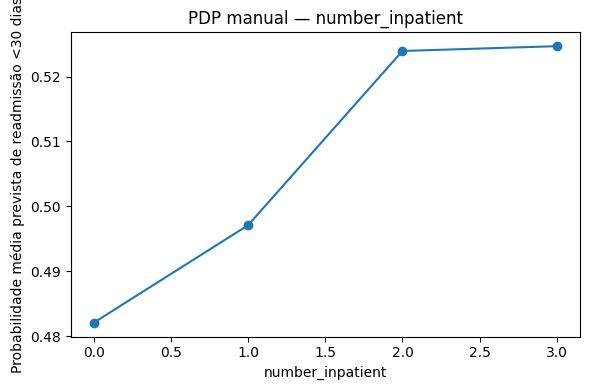

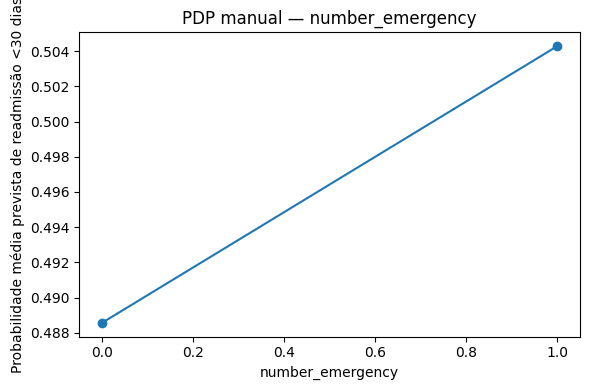

,feature,value,avg_predicted_probability
0,number_inpatient,0,0.482070
1,number_inpatient,1,0.497096
2,number_inpatient,2,0.523939
3,number_inpatient,3,0.524679
4,number_emergency,0,0.488566


In [26]:
# PDP manual para variáveis inteiras/discretas

from pathlib import Path

Path("../outputs/figuras").mkdir(parents=True, exist_ok=True)
Path("../outputs/tabelas").mkdir(parents=True, exist_ok=True)

# Amostra para tornar o cálculo mais rápido
X_pdp_sample = X_test.sample(n=3000, random_state=42).copy()

features_pdp = ["number_inpatient", "number_emergency"]

pdp_results = []

for feature in features_pdp:
    
    # Usar apenas valores até ao percentil 95 para evitar extremos muito raros
    max_value = int(X_pdp_sample[feature].quantile(0.95))
    values = sorted(X_pdp_sample[feature].unique())
    values = [v for v in values if v <= max_value]
    
    avg_predictions = []
    
    for value in values:
        X_temp = X_pdp_sample.copy()
        X_temp[feature] = value
        
        proba = best_rf_model.predict_proba(X_temp)[:, 1]
        avg_pred = proba.mean()
        
        avg_predictions.append(avg_pred)
        
        pdp_results.append({
            "feature": feature,
            "value": value,
            "avg_predicted_probability": avg_pred
        })
    
    # Gráfico PDP manual
    plt.figure(figsize=(6, 4))
    plt.plot(values, avg_predictions, marker="o")
    
    plt.title(f"PDP manual — {feature}")
    plt.xlabel(feature)
    plt.ylabel("Probabilidade média prevista de readmissão <30 dias")
    plt.tight_layout()
    
    plt.savefig(
        f"../outputs/figuras/pdp_manual_{feature}.png",
        dpi=300,
        bbox_inches="tight"
    )
    
    plt.show()

pdp_results_df = pd.DataFrame(pdp_results)

pdp_results_df.to_csv(
    "../outputs/tabelas/pdp_manual_random_forest.csv",
    index=False
)

pdp_results_df.head()

In [27]:
from pathlib import Path

files_to_check = [
    "../outputs/figuras/pdp_manual_number_inpatient.png",
    "../outputs/figuras/pdp_manual_number_emergency.png",
    "../outputs/tabelas/pdp_manual_random_forest.csv"
]

for file in files_to_check:
    print(file, "->", Path(file).exists())

../outputs/figuras/pdp_manual_number_inpatient.png -> True
../outputs/figuras/pdp_manual_number_emergency.png -> True
../outputs/tabelas/pdp_manual_random_forest.csv -> True


### Interpretação dos Partial Dependence Plots

Os gráficos de dependência parcial foram calculados manualmente para as variáveis `number_inpatient` e `number_emergency`, uma vez que estas variáveis são discretas e a função automática apresentou limitações com dados inteiros.

No caso de `number_inpatient`, observa-se uma relação crescente entre o número de internamentos anteriores e a probabilidade média prevista de readmissão em menos de 30 dias. À medida que o número de internamentos anteriores aumenta, o modelo tende a atribuir maior probabilidade de readmissão precoce.

No caso de `number_emergency`, observa-se também um aumento da probabilidade média prevista quando existe pelo menos um episódio anterior de urgência. Este resultado sugere que a utilização prévia de serviços de urgência pode estar associada a maior risco de readmissão em menos de 30 dias.

Estes resultados são coerentes com a análise de importância das variáveis, onde `number_inpatient` e `number_emergency` surgem entre os atributos mais relevantes. A interpretação é também clinicamente plausível, uma vez que pacientes com histórico de internamentos ou episódios de urgência tendem a apresentar maior complexidade clínica ou maior fragilidade.

## 3.7 Método local — LIME

O LIME permite explicar uma previsão individual aproximando localmente o comportamento do modelo com um modelo interpretável simples.

Neste projeto, será explicada uma observação do conjunto de teste classificada pelo modelo Random Forest afinado, identificando as variáveis que mais contribuíram para a previsão.

In [28]:
from lime.lime_tabular import LimeTabularExplainer

# Criar versão transformada dos dados para o LIME
X_train_transformed = best_rf_model.named_steps["preprocessor"].transform(X_train)
X_test_transformed = best_rf_model.named_steps["preprocessor"].transform(X_test)

# Converter para array denso numa amostra, para evitar problemas de memória
X_train_lime = X_train_transformed[:5000].toarray()
X_test_lime = X_test_transformed[:100].toarray()

feature_names_lime = best_rf_model.named_steps["preprocessor"].get_feature_names_out()

explainer = LimeTabularExplainer(
    training_data=X_train_lime,
    feature_names=feature_names_lime,
    class_names=["Não readmitido <30", "Readmitido <30"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

# Escolher uma instância do teste
instance_idx = 0

exp = explainer.explain_instance(
    data_row=X_test_lime[instance_idx],
    predict_fn=best_rf_model.named_steps["classifier"].predict_proba,
    num_features=10
)

exp.as_list()

[('cat__discharge_disposition_id_11 <= 0.00', 0.06074813828575415),
 ('cat__discharge_disposition_id_22 <= 0.00', -0.04548979666042104),
 ('cat__diag_3_574 <= 0.00', -0.03541232728171626),
 ('cat__diag_1_V58 <= 0.00', -0.03330173446101857),
 ('cat__diag_2_781 <= 0.00', -0.027901576329262764),
 ('cat__diag_1_235 <= 0.00', -0.024734705389650235),
 ('cat__diag_3_E929 <= 0.00', -0.02105070247977503),
 ('cat__diag_2_179 <= 0.00', 0.006194746645603498),
 ('cat__diag_1_380 <= 0.00', 0.003704775875748156),
 ('cat__diag_3_492 <= 0.00', -2.242844838563706e-05)]

In [29]:
lime_explanation = pd.DataFrame(
    exp.as_list(),
    columns=["feature", "contribution"]
)

lime_explanation.to_csv(
    "../outputs/tabelas/lime_explicacao_instancia.csv",
    index=False
)

lime_explanation

,feature,contribution
0,cat__discharge_disposition_id_11 <= 0.00,0.060748
1,cat__discharge_disposition_id_22 <= 0.00,-0.045490
2,cat__diag_3_574 <= 0.00,-0.035412
3,cat__diag_1_V58 <= 0.00,-0.033302
4,cat__diag_2_781 <= 0.00,-0.027902
5,cat__diag_1_235 <= 0.00,-0.024735
6,cat__diag_3_E929 <= 0.00,-0.021051
7,cat__diag_2_179 <= 0.00,0.006195
8,cat__diag_1_380 <= 0.00,0.003705
9,cat__diag_3_492 <= 0.00,-0.000022


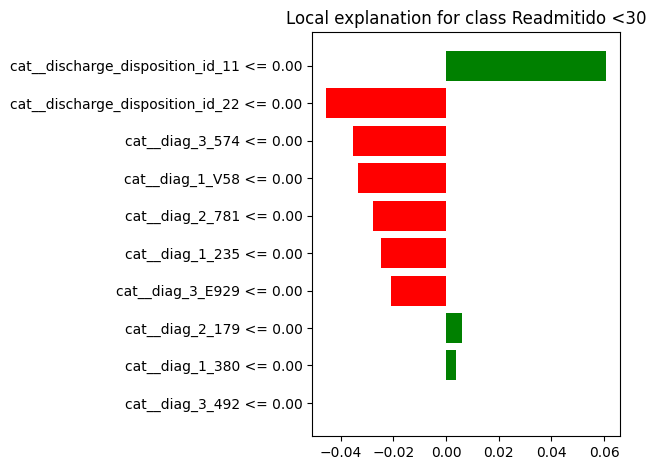

In [30]:
fig = exp.as_pyplot_figure()
plt.tight_layout()
plt.savefig("../outputs/figuras/lime_explicacao_instancia.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretação da explicação local com LIME

A explicação local com LIME mostra quais as variáveis que mais contribuíram para a previsão de uma instância específica do conjunto de teste.

No gráfico, as barras verdes representam fatores que contribuíram para aumentar a probabilidade prevista da classe `Readmitido <30`, enquanto as barras vermelhas representam fatores que contribuíram para reduzir essa probabilidade.

Nesta instância, a ausência ou presença de determinadas categorias associadas ao tipo de alta hospitalar e aos códigos de diagnóstico teve influência relevante na previsão local. A variável `discharge_disposition_id` volta a surgir como um elemento importante, em coerência com os resultados da Regressão Logística, da Árvore de Decisão e da importância global do Random Forest.

Deve notar-se que o LIME fornece uma explicação local, ou seja, válida apenas para esta observação específica. Por isso, não deve ser interpretado como uma explicação global do comportamento do modelo.

## 3.8 Explicações baseadas em exemplos

Nesta etapa são analisadas instâncias concretas do conjunto de teste, incluindo exemplos de verdadeiros positivos, falsos positivos e falsos negativos.

Esta análise permite compreender melhor o comportamento do modelo em casos individuais, identificando situações em que o modelo acerta e situações em que comete erros relevantes.

In [32]:
# Previsões do Random Forest afinado no conjunto de teste
y_pred_rf_final = best_rf_model.predict(X_test)
y_proba_rf_final = best_rf_model.predict_proba(X_test)[:, 1]

# Criar tabela com resultados reais, previstos e probabilidades
example_analysis = X_test.copy()
example_analysis["y_true"] = y_test
example_analysis["y_pred"] = y_pred_rf_final
example_analysis["prob_readmitted_30"] = y_proba_rf_final

# Verdadeiro positivo: real = 1 e previsto = 1
true_positive = example_analysis[
    (example_analysis["y_true"] == 1) & 
    (example_analysis["y_pred"] == 1)
].sort_values("prob_readmitted_30", ascending=False).head(1)

# Falso positivo: real = 0 e previsto = 1
false_positive = example_analysis[
    (example_analysis["y_true"] == 0) & 
    (example_analysis["y_pred"] == 1)
].sort_values("prob_readmitted_30", ascending=False).head(1)

# Falso negativo: real = 1 e previsto = 0
false_negative = example_analysis[
    (example_analysis["y_true"] == 1) & 
    (example_analysis["y_pred"] == 0)
].sort_values("prob_readmitted_30", ascending=True).head(1)

print("Verdadeiro positivo:")
display(true_positive)

print("Falso positivo:")
display(false_positive)

print("Falso negativo:")
display(false_negative)

Verdadeiro positivo:


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,y_true,y_pred,prob_readmitted_30
62759,Caucasian,Female,[20-30),1,1,7,3,36,0,15,...,No,No,No,No,No,Ch,Yes,1,1,0.627495


Falso positivo:


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,y_true,y_pred,prob_readmitted_30
93794,Caucasian,Female,[80-90),1,22,5,10,73,2,32,...,No,No,No,No,No,Ch,Yes,0,1,0.631226


Falso negativo:


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,y_true,y_pred,prob_readmitted_30
66599,Caucasian,Female,[50-60),5,1,1,1,34,1,5,...,No,No,No,No,No,No,No,1,0,0.389911


In [33]:
# Juntar os três exemplos numa tabela
examples_df = pd.concat([
    true_positive.assign(tipo_exemplo="Verdadeiro positivo"),
    false_positive.assign(tipo_exemplo="Falso positivo"),
    false_negative.assign(tipo_exemplo="Falso negativo")
])

examples_df.to_csv(
    "../outputs/tabelas/exemplos_previsoes_random_forest.csv",
    index=False
)

examples_df[[
    "tipo_exemplo",
    "y_true",
    "y_pred",
    "prob_readmitted_30",
    "number_inpatient",
    "number_emergency",
    "time_in_hospital",
    "num_medications",
    "number_diagnoses",
    "discharge_disposition_id"
]]

,tipo_exemplo,y_true,y_pred,prob_readmitted_30,number_inpatient,number_emergency,time_in_hospital,num_medications,number_diagnoses,discharge_disposition_id
62759,Verdadeiro positivo,1,1,0.627495,11,3,3,15,9,1
93794,Falso positivo,0,1,0.631226,4,3,10,32,9,22
66599,Falso negativo,1,0,0.389911,0,0,1,5,4,1


### Interpretação dos exemplos selecionados

Foram analisados três exemplos concretos do conjunto de teste: um verdadeiro positivo, um falso positivo e um falso negativo.

O verdadeiro positivo corresponde a uma observação em que o paciente foi efetivamente readmitido em menos de 30 dias e o modelo também previu essa readmissão. Este caso apresenta um número elevado de internamentos anteriores (`number_inpatient = 11`) e episódios de urgência (`number_emergency = 3`), o que é coerente com a importância atribuída pelo modelo a estas variáveis.

O falso positivo corresponde a uma observação em que o modelo previu readmissão em menos de 30 dias, mas essa readmissão não ocorreu. Este caso apresenta também histórico hospitalar relevante, incluindo internamentos anteriores, episódios de urgência, tempo de internamento elevado e número elevado de medicações. Isto sugere que o modelo pode estar a associar sinais de maior complexidade clínica a maior risco, mesmo quando a readmissão não se confirma.

O falso negativo corresponde a uma observação em que o paciente foi readmitido em menos de 30 dias, mas o modelo não previu essa readmissão. Este caso apresenta valores baixos em variáveis como `number_inpatient`, `number_emergency`, `time_in_hospital` e `num_medications`. Assim, o modelo classificou o paciente como tendo menor risco, mas a readmissão ocorreu. Este exemplo mostra que existem fatores não captados pelo modelo ou padrões difíceis de identificar apenas com as variáveis disponíveis.

## 3.9 Discussão da qualidade das explicações

A qualidade das explicações foi analisada considerando cinco critérios: transparência, fidelidade, consistência, simplicidade e relevância.

A Regressão Logística apresenta elevada transparência, porque os coeficientes permitem perceber diretamente quais as variáveis associadas ao aumento ou diminuição da probabilidade prevista de readmissão em menos de 30 dias. No entanto, devido ao elevado número de variáveis resultantes da codificação das categorias, a simplicidade da explicação diminui.

A Árvore de Decisão também apresenta boa transparência, uma vez que a sua estrutura pode ser representada por regras hierárquicas. A variável `number_inpatient` surgiu como principal critério de separação, o que é coerente com a análise exploratória e com os métodos de importância das variáveis. Contudo, árvores mais profundas tornam-se rapidamente difíceis de interpretar, pelo que foi apresentada apenas uma estrutura parcial.

No Random Forest, a transparência direta é menor, porque o modelo combina múltiplas árvores. Para compensar esta limitação, foram utilizados métodos globais, como a importância das variáveis e a Permutation Importance. Estes métodos mostraram resultados consistentes, destacando `number_inpatient`, `discharge_disposition_id`, `number_emergency`, diagnósticos e medicação como variáveis relevantes.

Os Partial Dependence Plots permitiram observar o efeito médio de variáveis específicas na probabilidade prevista. Os resultados mostraram que o aumento de `number_inpatient` e `number_emergency` está associado ao aumento da probabilidade média prevista de readmissão em menos de 30 dias.

O LIME foi utilizado como método local para explicar uma previsão individual. Esta explicação é útil para compreender uma decisão específica, mas deve ser interpretada com prudência, pois não representa necessariamente o comportamento global do modelo.

As explicações baseadas em exemplos permitiram comparar casos de verdadeiro positivo, falso positivo e falso negativo. Esta análise mostrou que o modelo tende a atribuir maior risco a pacientes com maior histórico hospitalar, mas também pode gerar falsos positivos em pacientes clinicamente complexos que não acabam por ser readmitidos, e falsos negativos em pacientes com poucos sinais de risco nas variáveis disponíveis.

De forma geral, as explicações apresentaram boa relevância e consistência, pois diferentes métodos destacaram variáveis semelhantes. No entanto, existem limitações na interpretação clínica dos códigos de diagnóstico e das categorias administrativas, que exigiriam uma tabela de mapeamento clínico mais detalhada.